# Titanic Data Analysis
## Feature Engineering
- *Goal*: refine feature engineering (age binning, extract deck from cabin, use ticket to check for groups beside the family size) to improve passenger prediction

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Dataframe
df = pd.read_csv('Titanic_Train.csv')
print('--Data Load')

--Data Load


In [3]:
# General inspection of the Dataframe with head(), info() and insa().sum()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# Filling missing values in Cabin with 'unknown' and extracting Deck
df['Cabin'] = df['Cabin'].fillna('Unknown')

# Extracting the first letter from the non-missing values
df['Deck'] = df['Cabin'].str[0]

# Checking the values
print(df['Deck'].unique())

['U' 'C' 'E' 'G' 'D' 'A' 'B' 'F' 'T']


**Note:** In the previous FE file the Cabin values were changed into hasCabin with 0 = False and 1 = True, now the first letter was extracted to improve the feature engineering for a better passenger prediction later. <br>
The U Deck is for 'unkown'

In [7]:
print(df.groupby('Deck')['Survived'].mean())

Deck
A    0.466667
B    0.744681
C    0.593220
D    0.757576
E    0.750000
F    0.615385
G    0.500000
T    0.000000
U    0.299854
Name: Survived, dtype: float64


**Note:** Best decks: B, D and E with a survival rate over 70%, except deck C which shows a survival rate of only 59%. The survival rate on deck F and G and the unknown decks are significant lower which indicates, that in these decks are more down in the ship and mostly used by passengers traveling in the third class. 

In [8]:
# Extracting the title of the name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Checking the unqiue values of the title
print(df['Title'].unique())
print(df['Title'].value_counts())

['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'Countess' 'Jonkheer']
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64


In [9]:
# Replacing and shortend the titles to only 4 in total
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Lady', 'Mrs')

# Check if it worked
print(df['Title'].unique())

['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Major' 'Sir' 'Col' 'Capt'
 'Countess' 'Jonkheer']


In [10]:
# Group all the other title into a list 
unknown_title = ['Don', 'Rev', 'Dr', 'Major', 'Sir', 'Col', 'Capt', 'Countess', 'Jonkheer']
# Replacing all the unknown title into 'unknown'
df['Title'] = df['Title'].replace(unknown_title, 'unknown')
# Check if it worked and count the values
print(df['Title'].unique())
print(df['Title'].value_counts())

['Mr' 'Mrs' 'Miss' 'Master' 'unknown']
Title
Mr         517
Miss       185
Mrs        127
Master      40
unknown     22
Name: count, dtype: int64


In [11]:
# Filling the missing age values with the median age grouped by title
df['Age'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))

In [12]:
# Check the median age of each group
print(df.groupby('Title')['Age'].median())

Title
Master      3.5
Miss       21.0
Mr         30.0
Mrs        35.0
unknown    49.0
Name: Age, dtype: float64


In [13]:
# Creating new and finer age bins for a better seperation
fine_age_bins = [-1, 1, 5, 12, 16, 30, 55, 100]
fine_age_labels = ['Infant', 'Toddler', 'Child', 'Teenager', 'Young_Adult', 'Adult', 'Senior']

df['Fine_Age_Group'] = pd.cut(df['Age'], bins=fine_age_bins, labels=fine_age_labels)

# Check if it worked
print(df.groupby('Fine_Age_Group', observed=False)['Survived'].mean())

Fine_Age_Group
Infant         0.857143
Toddler        0.617647
Child          0.360000
Teenager       0.483871
Young_Adult    0.316810
Adult          0.445230
Senior         0.300000
Name: Survived, dtype: float64


**Note:** Best survival chance was for Infant and Toddler with a survival rate of above of 60%. senior passengers with an age over 55 years had the worst survival rate, while the passengers inbetween senior and toddler had a survival rate of mostly 40%

In [14]:
# Adding new column 'FamilySize'
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Check if it worked
print(df['FamilySize'].value_counts())

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64


In [15]:
# Changing the gender column to binary by get_dummies() function
df = pd.get_dummies(df, columns=['Sex'], drop_first=False, dtype=int)

# Check the columns
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'Deck', 'Title',
       'Fine_Age_Group', 'FamilySize', 'Sex_female', 'Sex_male'],
      dtype='object')


In [16]:
# Adding new column 'isAlone' with default value 0
df['isAlone'] = 0

# Replacing the values, if passenger is alone change to 1
# if passenger is traveling at least one additional person it is still 0
df.loc[df['FamilySize'] == 1, 'isAlone'] = 1

# Check if it works
print(df['isAlone'].describe())

count    891.000000
mean       0.602694
std        0.489615
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: isAlone, dtype: float64


In [17]:
# Checking the data frame of isna().sum()
print(df.isna().sum())

PassengerId       0
Survived          0
Pclass            0
Name              0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin             0
Embarked          2
Deck              0
Title             0
Fine_Age_Group    0
FamilySize        0
Sex_female        0
Sex_male          0
isAlone           0
dtype: int64


In [18]:
# Filling the two missing values in the 'embarked' column with the mode function
most_freq_emb_ports = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_freq_emb_ports)

# Check again for missing values and if it worked
print(df.isna().sum())

PassengerId       0
Survived          0
Pclass            0
Name              0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin             0
Embarked          0
Deck              0
Title             0
Fine_Age_Group    0
FamilySize        0
Sex_female        0
Sex_male          0
isAlone           0
dtype: int64


In [19]:
# Preparing the column 'Embarked' with the pd.get_dummies function and convert the data
df = pd.get_dummies(df, columns=['Embarked'], drop_first=False, dtype=int)

# Check if it works
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Deck', 'Title', 'Fine_Age_Group',
       'FamilySize', 'Sex_female', 'Sex_male', 'isAlone', 'Embarked_C',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [20]:
# Splitting the fare prices into 5 categories
df['FareCategory'] = pd.qcut(df['Fare'], q=5, labels = ['very_cheap', 'low', 'medium', 'high', 'luxury'])

# Check if it works
print(df['FareCategory'].value_counts())
# Checking for the new fare ranges
print(pd.qcut(df['Fare'], q=5).value_counts())

FareCategory
low           184
high          180
very_cheap    179
luxury        176
medium        172
Name: count, dtype: int64
Fare
(7.854, 10.5]        184
(21.679, 39.688]     180
(-0.001, 7.854]      179
(39.688, 512.329]    176
(10.5, 21.679]       172
Name: count, dtype: int64


In [21]:
# Analyse the head again, to check if there is some additional column wich can be used for ml
# and was droped in the previos notebook
df.head(50)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Title,Fine_Age_Group,FamilySize,Sex_female,Sex_male,isAlone,Embarked_C,Embarked_Q,Embarked_S,FareCategory
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,Unknown,...,Mr,Young_Adult,2,0,1,0,0,0,1,very_cheap
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,...,Mrs,Adult,2,1,0,0,1,0,0,luxury
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,Unknown,...,Miss,Young_Adult,1,1,0,1,0,0,1,low
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,...,Mrs,Adult,2,1,0,0,0,0,1,luxury
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,Unknown,...,Mr,Adult,1,0,1,1,0,0,1,low
5,6,0,3,"Moran, Mr. James",30.0,0,0,330877,8.4583,Unknown,...,Mr,Young_Adult,1,0,1,1,0,1,0,low
6,7,0,1,"McCarthy, Mr. Timothy J",54.0,0,0,17463,51.8625,E46,...,Mr,Adult,1,0,1,1,0,0,1,luxury
7,8,0,3,"Palsson, Master. Gosta Leonard",2.0,3,1,349909,21.0750,Unknown,...,Master,Toddler,5,0,1,0,0,0,1,medium
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",27.0,0,2,347742,11.1333,Unknown,...,Mrs,Young_Adult,3,1,0,0,0,0,1,medium
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",14.0,1,0,237736,30.0708,Unknown,...,Mrs,Teenager,2,1,0,0,1,0,0,high


**Thought:** If there is any context in the tickets. Checking with value counts

In [22]:
# Check with value counts if there is a pattern in the tickets
print(df['Ticket'].value_counts())

Ticket
347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
           ..
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name: count, Length: 681, dtype: int64


**Note:** The number of tickets indicates that there were group tickets, suggesting that some passengers travelled alone but shared a ticket, as was the case in third class where sleeping compartments where shared. Similary, there may be shared tickets for passengers travelling in the first class whose companions were accomodated in second or third class.

In [23]:
# Adding a new colum 'TicketGroupSize' 
df['TicketGroupSize'] = df.groupby('Ticket')['Ticket'].transform('count')

# Checking the values
print(df['TicketGroupSize'].value_counts())

TicketGroupSize
1    547
2    188
3     63
4     44
7     21
6     18
5     10
Name: count, dtype: int64


In [24]:
# Checking the survival rate by ticket group size
print(df.groupby('TicketGroupSize')['Survived'].mean())

TicketGroupSize
1    0.297989
2    0.574468
3    0.698413
4    0.500000
5    0.000000
6    0.000000
7    0.238095
Name: Survived, dtype: float64


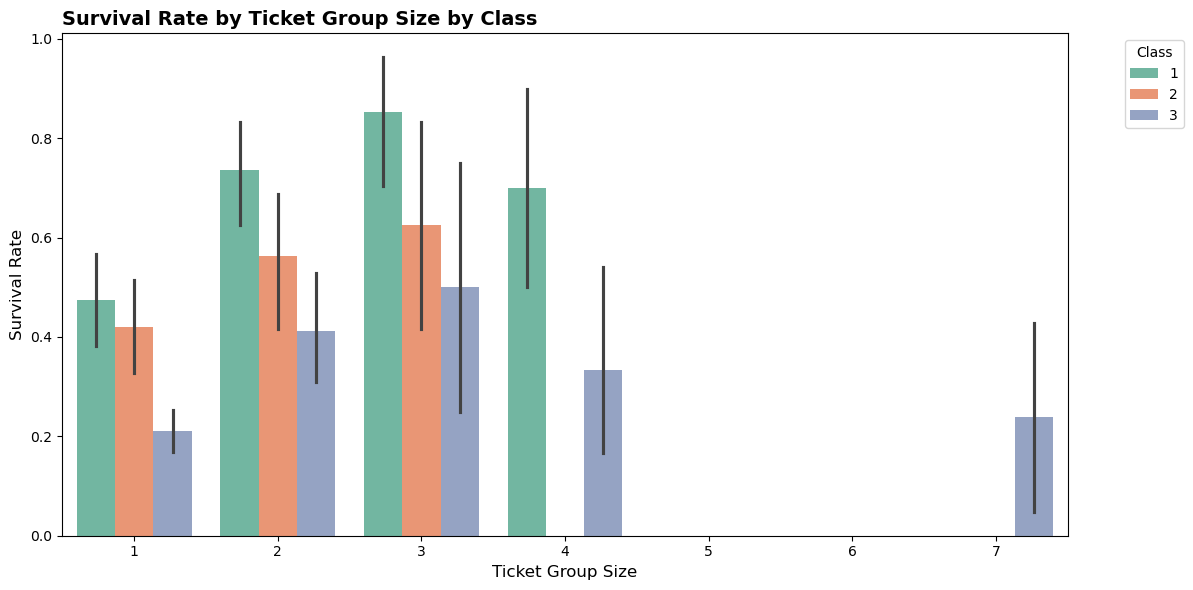

In [25]:
# Visualize the survival rate by ticket group size by class
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='TicketGroupSize', y='Survived', hue='Pclass', palette='Set2')
plt.title('Survival Rate by Ticket Group Size by Class', fontsize=14, fontweight='bold', loc='left')
plt.xlabel('Ticket Group Size', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Class')
plt.tight_layout()
plt.show()

**Analysis:** The chart reveals that passengers in first and second class mostly traveled in small groups of 2 or 3 people, likely family members or close companions. These small groups show the highest survival rates, reaching almost 80% for first-class passengers with a ticket group size of 3. 
In contrast, larger ticket groups are predominantly found in third class, where the survival rate drops significantly to around 20% or lower. 
The visualization also demonstrates that in first class, survival chances actually increased when traveling with one or two companions compared to traveling completely alone. This indicates that being part of a small group (up to 3 people) was highly advantageous, suggesting that passengers were able to support and take care of each other during the evacuation.

In [27]:
# Check all the columns
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Deck', 'Title', 'Fine_Age_Group',
       'FamilySize', 'Sex_female', 'Sex_male', 'isAlone', 'Embarked_C',
       'Embarked_Q', 'Embarked_S', 'FareCategory', 'TicketGroupSize'],
      dtype='object')

In [29]:
# Replacing the columns 'Deck', 'Title', 'Fine_Age_Group', 'FareCategory' into binary values
df = pd.get_dummies(df, columns=['Deck', 'Title', 'Fine_Age_Group', 'FareCategory'], drop_first=False, dtype=int)

# Check if it works
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'FamilySize', 'Sex_female', 'Sex_male',
       'isAlone', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'TicketGroupSize',
       'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G',
       'Deck_T', 'Deck_U', 'Title_Master', 'Title_Miss', 'Title_Mr',
       'Title_Mrs', 'Title_unknown', 'Fine_Age_Group_Infant',
       'Fine_Age_Group_Toddler', 'Fine_Age_Group_Child',
       'Fine_Age_Group_Teenager', 'Fine_Age_Group_Young_Adult',
       'Fine_Age_Group_Adult', 'Fine_Age_Group_Senior',
       'FareCategory_very_cheap', 'FareCategory_low', 'FareCategory_medium',
       'FareCategory_high', 'FareCategory_luxury'],
      dtype='object')

In [30]:
# Drop the unnecessary columns which are not relevant for ml model
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']

df_ml_detailed = df.drop(columns=(columns_to_drop))

# Check if it works
df_ml_detailed.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'Sex_female', 'Sex_male', 'isAlone', 'Embarked_C', 'Embarked_Q',
       'Embarked_S', 'TicketGroupSize', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D',
       'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_U', 'Title_Master',
       'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_unknown',
       'Fine_Age_Group_Infant', 'Fine_Age_Group_Toddler',
       'Fine_Age_Group_Child', 'Fine_Age_Group_Teenager',
       'Fine_Age_Group_Young_Adult', 'Fine_Age_Group_Adult',
       'Fine_Age_Group_Senior', 'FareCategory_very_cheap', 'FareCategory_low',
       'FareCategory_medium', 'FareCategory_high', 'FareCategory_luxury'],
      dtype='object')

In [31]:
# Save the df_ml_detailed into a new .csv for ml model
df_ml_detailed.to_csv('Titanic_for_ML_detailed.csv', index=False)